In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
N = 300

def rhs(t, F, params):
    """
    Right-hand side for the system F0..F8.
    F is ordered [F0, F1, F2, F3, F4, F5, F6, F7, F8].
    params is a dict containing: k_avg, lam1, lam2, mu, mu_bar
    """
    k = params['k_avg']
    lam1 = params['lam1']
    lam2 = params['lam2']
    mu = params['mu']
    mu_bar = params['mu_bar']
    
    F0, F1, F2, F3, F4, F5, F6, F7, F8 = F

    # common combinations
    comb1 = F1 + F4 + F7
    comb2 = F3 + F4 + F5

    dF0 = -k * lam1 * F0 * comb1 - k * lam2 * F0 * comb2
    dF1 = -F1 * mu - k * lam2 * F1 * comb2 + k * lam1 * F0 * comb1
    dF2 = F1 * mu - k * F2 * lam2 * comb2
    dF3 = -k * lam1 * F3 * comb1 - F3 * mu + k * lam2 * F0 * comb2
    dF4 = k * lam1 * F3 * comb1 + k * lam2 * F1 * comb2 - F4 * mu_bar
    dF5 = k * lam2 * F2 * comb2 - F5 * mu
    dF6 = -k * lam1 * F6 * comb1 + F3 * mu
    dF7 = k * lam1 * F6 * comb1 - F7 * mu
    dF8 = F4 * mu_bar + F7 * mu + F5 * mu

    return [dF0, dF1, dF2, dF3, dF4, dF5, dF6, dF7, dF8]


# --- Initial conditions (placeholders a,b,c,... fill these) ---
# Order: F0, F1, F2, F3, F4, F5, F6, F7, F8
y0 = [(N-2)/N, 1/N, 0, 1/N, 0, 0, 0, 0, 0]  # replace a,b,...,i with numeric values

# --- Time span and evaluation times ---
t_span = (0.0, 50.0)               # start and end time
t_eval = np.linspace(t_span[0], t_span[1], 501)


In [6]:
l1_range = np.linspace(0.1, 1.5, 200)

l2_range = np.linspace(0.1, 1.5, 200)

final_fractions = []

for l1 in l1_range:
    final = []
    for l2 in l2_range:
        params = {
            'k_avg': 1,    # <k>
            'lam1': l1,     # lambda_1
            'lam2': l2,     # lambda_2
            'mu': 1.0,       # mu
            'mu_bar': 1.0,    # \bar{\mu}
            }

        sol = solve_ivp(lambda t, y: rhs(t, y, params),
                    t_span, y0, t_eval=t_eval, method='RK45', atol=1e-8, rtol=1e-6)
    
        R = sol.y[2] + sol.y[5] + sol.y[6] + sol.y[7] + sol.y[8]
        
        final.append(R[-1])
    final_fractions.append(final)        

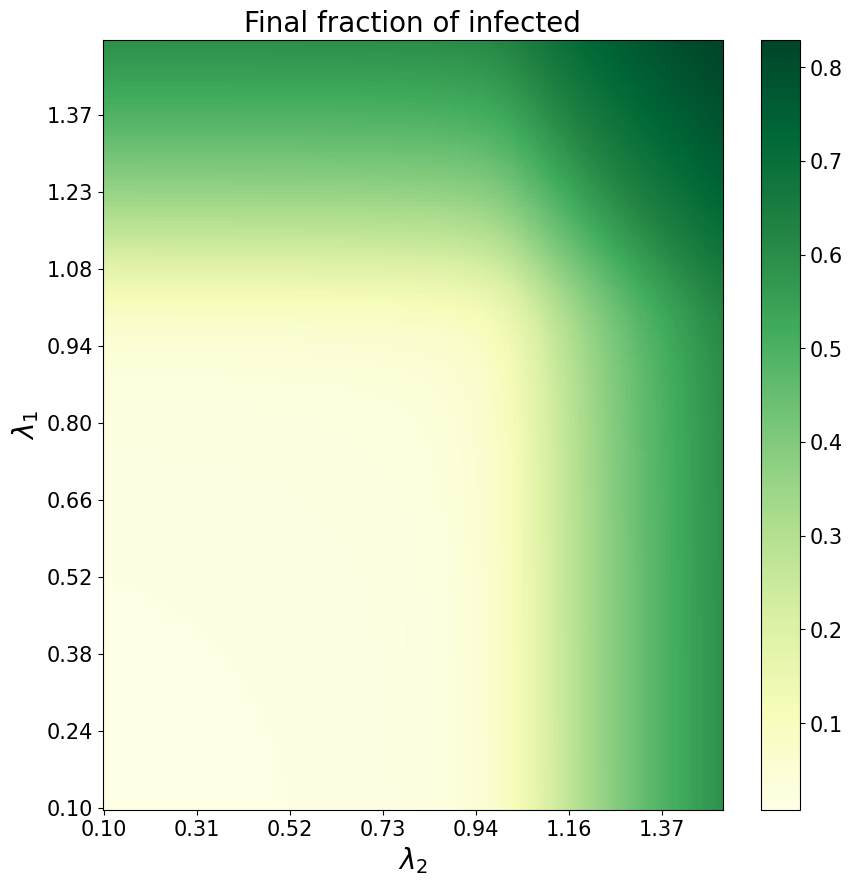

In [8]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)  

ax.imshow(final_fractions, cmap='YlGn', aspect='auto', origin='lower')
cbar = plt.colorbar(ax.images[0]) 
ax.set_xlabel(r"$\lambda_2$", fontsize=20)
ax.set_ylabel(r"$\lambda_1$", fontsize=20)

n = 20
ax.set_xticks(range(0, len(l2_range), n+10))
ax.set_xticklabels([f'{x:.2f}' for x in l2_range[::n+10]], fontsize=15)

ax.set_yticks(range(0, len(l1_range), n))
ax.set_yticklabels([f'{x:.2f}' for x in l1_range[::n]], fontsize=15)

ax.set_title("Final fraction of infected", fontsize=20)
cbar.ax.tick_params(labelsize=15)
plt.show()

## 3D attempt

In [63]:
from matplotlib import cm

In [104]:
mu_bar_range = np.linspace(.5, 1.5, 200)

In [105]:
Lrange = np.linspace(.5, 1.5, 200)

In [106]:
peaks = []

In [107]:
for L in Lrange:
    peak = []
    for m in mu_bar_range:
        params = {
            'k_avg': 10,    # <k>
            'lam1': L,     # lambda_1
            'lam2': L,     # lambda_2
            'mu': 1.0,       # mu
            'mu_bar': m    # \bar{\mu}
            }

        sol = solve_ivp(lambda t, y: rhs(t, y, params),
                    t_span, y0, t_eval=t_eval, method='RK45', atol=1e-8, rtol=1e-6)
    
        i_A = sol.y[1] + sol.y[4] + sol.y[7]
        i_B = sol.y[3] + sol.y[4] + sol.y[5]
        J = i_A + i_B - sol.y[4]
        
        peak.append(max(J))
    peaks.append(peak)        

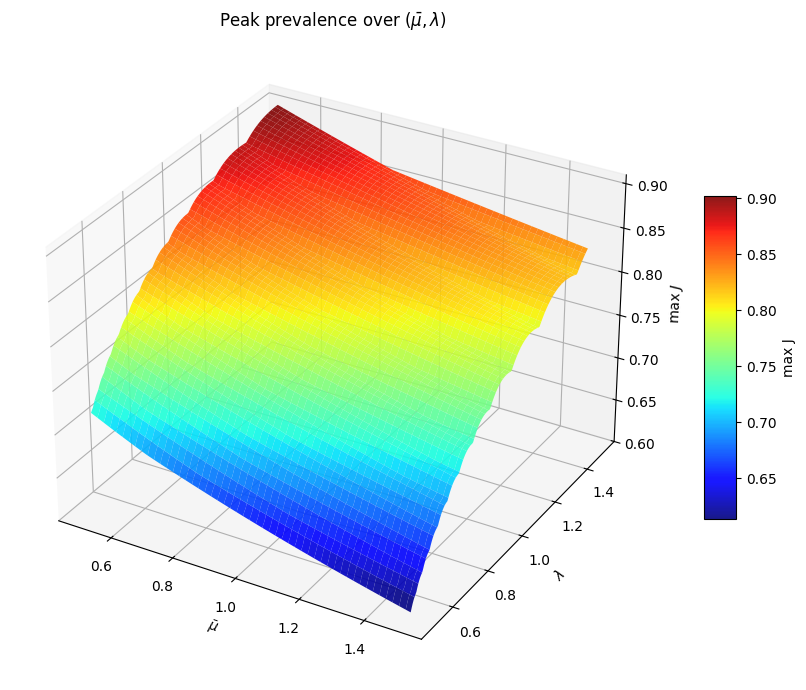

In [80]:
Z = np.array(peaks)  # shape: (len(Lrange), len(mu_bar_range))
X, Y = np.meshgrid(mu_bar_range, Lrange)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap=cm.jet, edgecolor='none', alpha=0.9)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='max J')

ax.set_xlabel(r'$\bar{\mu}$')
ax.set_ylabel(r'$\lambda$')
ax.set_zlabel(r'$\max \, \, J$')
ax.set_title(r'Peak prevalence over $(\bar{\mu}, \lambda)$')

plt.tight_layout()
plt.show()

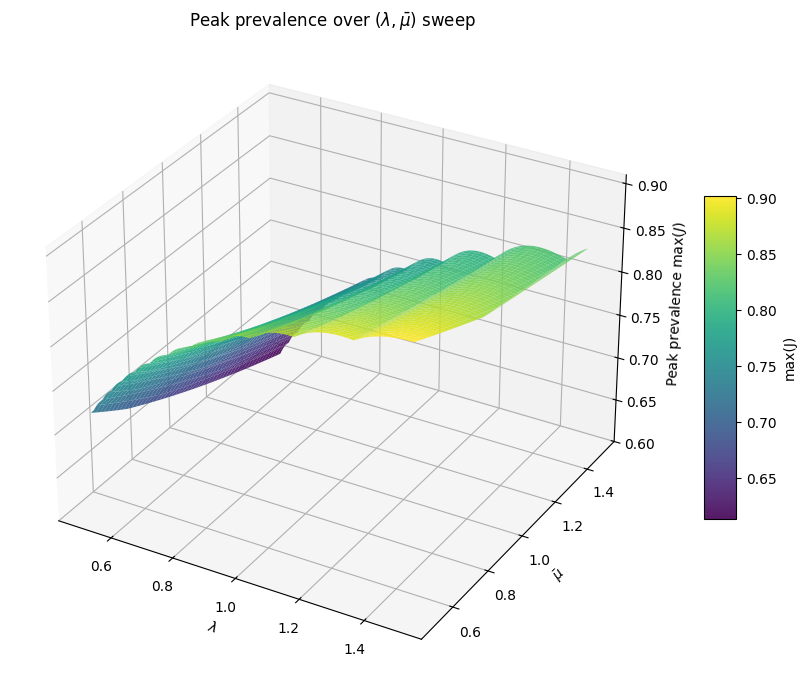

In [65]:

Z = np.array(peaks).T  # transpose since we're swapping axes
X, Y = np.meshgrid(Lrange, mu_bar_range)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis, edgecolor='none', alpha=0.9)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='max(J)')

ax.set_xlabel(r'$\lambda$')
ax.set_ylabel(r'$\bar{\mu}$')
ax.set_zlabel(r'Peak prevalence $\max(J)$')
ax.set_title(r'Peak prevalence over $(\lambda, \bar{\mu})$ sweep')

plt.tight_layout()
plt.show()

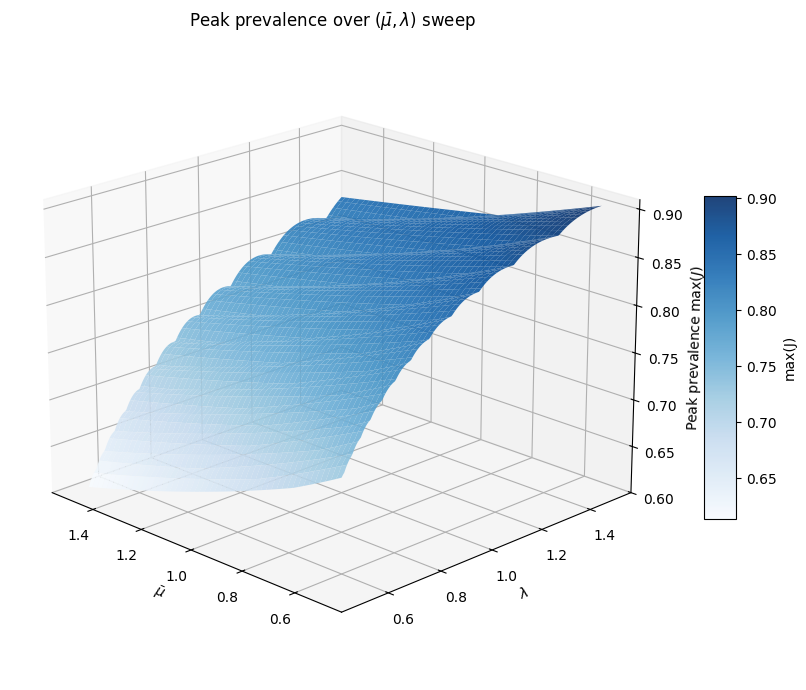

In [69]:
Z = np.array(peaks)  # shape: (len(Lrange), len(mu_bar_range))
X, Y = np.meshgrid(mu_bar_range, Lrange)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap=cm.Blues, edgecolor='none', alpha=0.9)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='max(J)')

ax.set_xlabel(r'$\bar{\mu}$')
ax.set_ylabel(r'$\lambda$')
ax.set_zlabel(r'Peak prevalence $\max(J)$')
ax.set_title(r'Peak prevalence over $(\bar{\mu}, \lambda)$ sweep')

# X-axis pointing towards viewer, Y-axis to the right, Z-axis up
ax.view_init(elev=20, azim=-45)
ax.invert_xaxis()

plt.tight_layout()
plt.show()

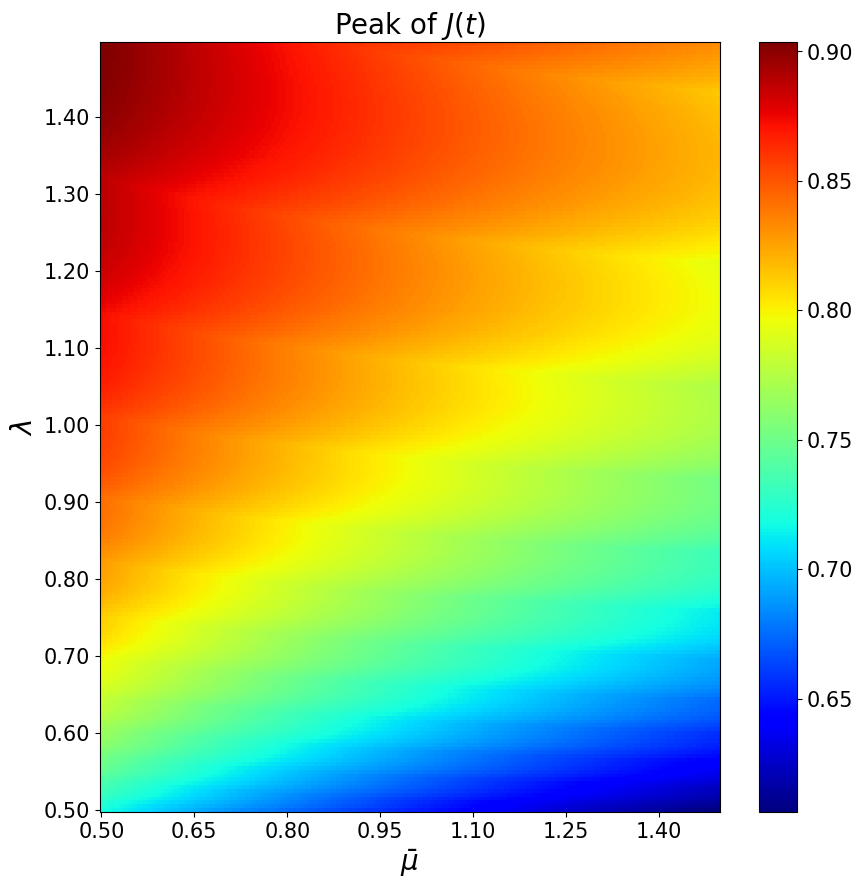

In [108]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)  # add this line
ax.imshow(peaks, cmap='jet', aspect='auto', origin='lower')
cbar = plt.colorbar(ax.images[0])  # need to reference the image for colorbar
ax.set_xlabel(r"$\bar{\mu}$", fontsize=20)
ax.set_ylabel(r"$\lambda$", fontsize=20)

n = 20
ax.set_xticks(range(0, len(mu_bar_range), n+10))
ax.set_xticklabels([f'{x:.2f}' for x in mu_bar_range[::n+10]], fontsize=15)
ax.set_yticks(range(0, len(Lrange), n))
ax.set_yticklabels([f'{x:.2f}' for x in Lrange[::n]], fontsize=15)
ax.set_title("Peak of $J(t)$", fontsize=20)
cbar.ax.tick_params(labelsize=15)
plt.savefig("peak_jet.png", dpi=300, bbox_inches="tight")